Importing Necessary Dependencies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
np.random.seed(1)

**Problem 1**

In [2]:
def func_gradient(x):
    return np.array([-2 + 2 * x[0] - (400 * (x[1] - x[0] ** 2) * x[0]), 200 * (x[1] - x[0] ** 2)])

# Since both terms of the function involves squaring, there is no point on the function where f(x_1, x_2) < 0. Therefore, if we look at the pair (1, 1), we get that f(1, 1) = 0, which is the optimal solution.

Gradient Descent Final Value: [0.99888299 0.99776276] over 151234 iterations.


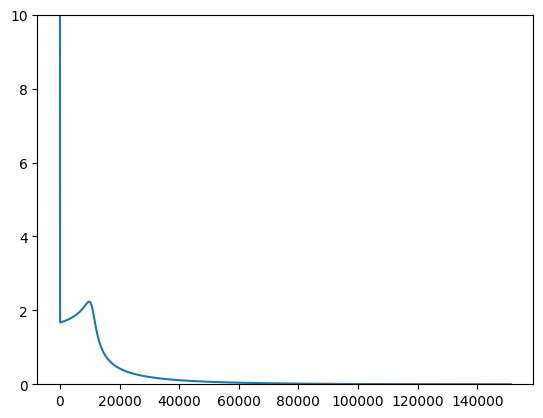

In [ ]:
init_x = np.array([-1.5, 1.5])
def gradient_descent(X, step_size=0.0001, stop_cond=0.001, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        X = X - step_size * grad
    return [X, iterations, gradient_norm]

grad_desc_vals = gradient_descent(init_x)
print("Gradient Descent Final Value:", grad_desc_vals[0], "over", grad_desc_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_vals[1])], grad_desc_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()

Gradient Descent (Momentum) Final Value: [0.98891882 0.97791579] over 94067 iterations.


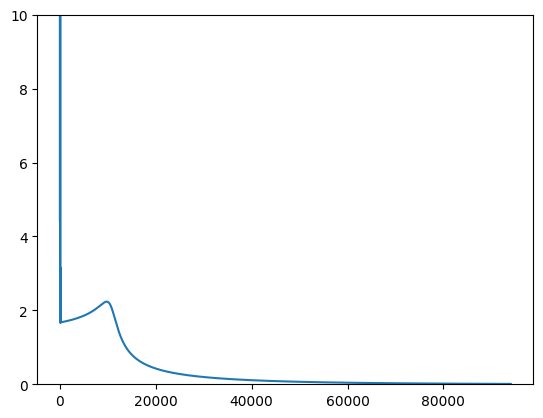

In [ ]:
def gradient_descent_mmt(X, beta=0.90, step_size=0.0001, stop_cond=0.01, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    v = np.array([0, 0])
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        v = beta * v + (1 - beta) * grad
        X = X - step_size * v
    return [X, iterations, gradient_norm]

grad_desc_mmt_vals = gradient_descent_mmt(init_x)
print("Gradient Descent (Momentum) Final Value:", grad_desc_mmt_vals[0], "over", grad_desc_mmt_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_mmt_vals[1])], grad_desc_mmt_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()
        

Gradient Descent (Momentum) Final Value: [1.0000485 0.999947 ] over 1000000 iterations.


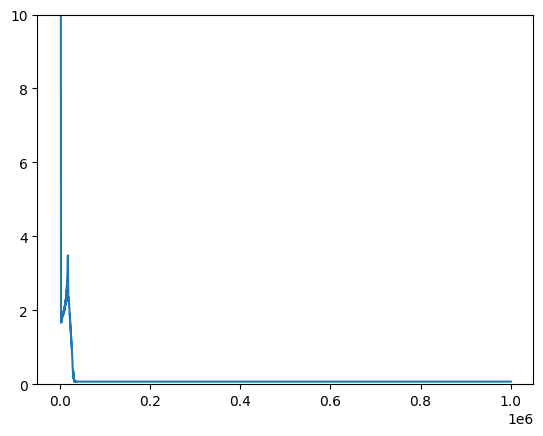

In [40]:
def gradient_descent_RMS(X, gamma=0.99, epsilon = 0.00000001, step_size=0.0001, stop_cond=0.01, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    s = np.array([1, 1])
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        s = gamma * s + (1 - gamma) * np.square(grad)
        X = X - step_size * (grad / (np.sqrt(s + epsilon)))
    return [X, iterations, gradient_norm]

grad_desc_RMS_vals = gradient_descent_RMS(init_x)
print("Gradient Descent (Momentum) Final Value:", grad_desc_RMS_vals[0], "over", grad_desc_RMS_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_RMS_vals[1])], grad_desc_RMS_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()

Gradient Descent (Momentum) Final Value: [0.98907823 0.97823514] over 33674 iterations.


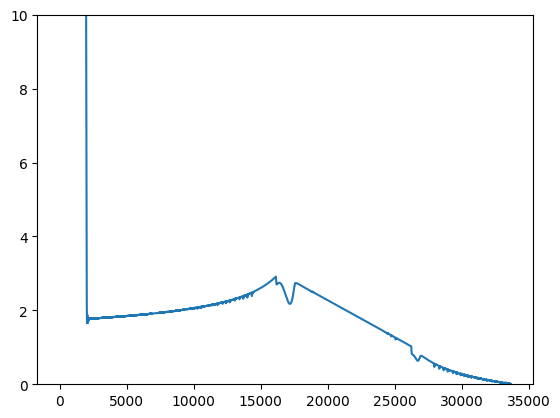

In [ ]:
def gradient_descent_adam(X, beta=0.9, gamma=0.9, epsilon = 0.00000001, step_size=0.0001, stop_cond=0.01, max_iterations=1000000):
    iterations = 0
    gradient_norm = []
    s = np.array([1, 1])
    v = np.array([0, 0])
    for _ in range(max_iterations):
        iterations += 1
        grad = func_gradient(X)
        norm_grad = np.linalg.norm(grad)
        gradient_norm.append(norm_grad)
        if norm_grad < stop_cond:
            return [X, iterations, gradient_norm]
        v = beta * v + (1 - beta) * grad
        s = gamma * s + (1 - gamma) * np.square(grad)
        X = X - step_size * (v / (np.sqrt(s + epsilon)))
    return [X, iterations, gradient_norm]

grad_desc_adam_vals = gradient_descent_adam(init_x)
print("Gradient Descent (Momentum) Final Value:", grad_desc_adam_vals[0], "over", grad_desc_adam_vals[1], "iterations.")
plt.plot([i for i in range(grad_desc_adam_vals[1])], grad_desc_adam_vals[2])
plt.ylim(top=10, bottom=0)
plt.show()